In [3]:
import numpy as  np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from typing import Union, Dict, Tuple
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## Table of Contents

- Feature Description
- Baseline Model
- Baseline Model Lag Features
- Conclusions

## Feature Description

In [6]:
## Loading the data
data = pd.read_parquet('../data/01_raw/bike_data_train.parquet')
data.head(3)

,datetime,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,2011-01-01 00:00:00,1,0,0,6,1,0.24,0.81,0.0,16
1,2011-01-01 01:00:00,1,1,0,6,1,0.22,0.80,0.0,40
2,2011-01-01 02:00:00,1,2,0,6,1,0.22,0.80,0.0,32


In [7]:
data.columns


Index(['datetime', 'season', 'hr', 'holiday', 'weekday', 'weathersit', 'temp',
       'hum', 'windspeed', 'cnt'],
      dtype='str')

In [8]:
drop_cols = ['datetime']

In [9]:
data = data.drop(columns=drop_cols)

In [10]:
data.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt
0,1,0,0,6,1,0.24,0.81,0.0,16
1,1,1,0,6,1,0.22,0.80,0.0,40
2,1,2,0,6,1,0.22,0.80,0.0,32


## Baseline Model

We will use CatBoost with raw features as a model.
Then, we will add features and try other algorithms to see how big the improvement is.
For the metrics, we will use:
- MAPE - Mean Absolute Percentage Error (in %)
- MAE - Mean Absolute Erro
- RMSE: Root Mean Squared Error

In [34]:
def compute_metrics(
    y_true: Union[np.ndarray, list],
    y_pred: Union[np.ndarray, list]
) -> Dict[str, float]:
    """
    Compute evaluation metrics between true and predicted values.

    Metrics returned:
    - MAPE: Mean Absolute Percentage Error (in %)
    - MAE: Mean Absolute Error
    - RMSE: Root Mean Squared Error

    Parameters:
    ----------
    y_true : array-like
        Ground truth values.
    y_pred : array-like
        Predicted values.

    Returns:
    -------
    dict
        Dictionary with keys 'MAPE', 'MAE', and 'RMSE' and their float values.
    """
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mape = np.mean(np.abs((y_true - y_pred) / y_true + 1e-8)) * 100

    return {
        'MAE': float(round(mae, 2)),
        'RMSE': float(round(rmse, 2)),
        'MAPE': float(round(mape, 2)),
    }
    

In [35]:
def prepare_dataset(
    df: pd.DataFrame,
    train_fraction: float =0.8
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """
    Splits a DataFrame into training and testing sets for features and target.

    Parameters:
    ----------
    df : pd.DataFrame
        The input DataFrame that must contain a 'target' column.
    train_fraction : float, optional (default=0.8)
        The fraction of data to use for training (between 0 and 1).

    Returns:
    -------
    x_train : pd.DataFrame
        Training features.
    x_test : pd.DataFrame
        Testing features.
    y_train : pd.Series
        Training target values.
    y_test : pd.Series
        Testing target values.
    """
    feats = [col for col in df.columns if col != 'target']
    x, y =  df[feats], df['target']
    train_size = int(train_fraction *df.shape[0])
    x_train, x_test = x[:train_size], x[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    return x_train, x_test, y_train, y_test

## Target Definition

In [36]:
df = data.copy()

In [37]:
df['target'] = df['cnt'].shift(-1).ffill()
df.drop(columns=['cnt'], inplace=True)

In [38]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,target
0,1,0,0,6,1,0.24,0.81,0.0,40.0
1,1,1,0,6,1,0.22,0.80,0.0,32.0
2,1,2,0,6,1,0.22,0.80,0.0,13.0


## Fitting the Model

In [39]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [40]:
params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

## Tuning with early stopping]
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

## Baseline Prediction

In [41]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 85.27, 'RMSE': 116.06, 'MAPE': 43.99}

Text(0.5, 1.0, 'Rented Bike Count, 1-h Forecast, Baseline')

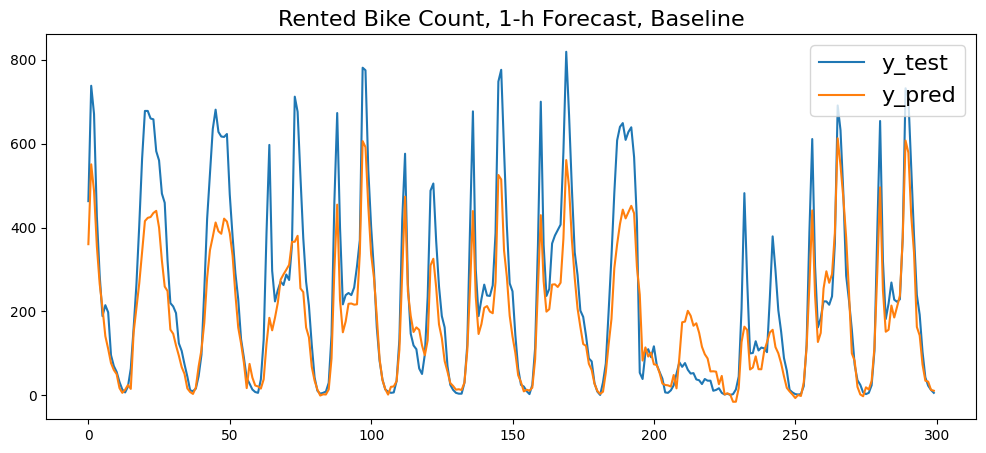

In [43]:
n = 300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Rented Bike Count, 1-h Forecast, Baseline', fontsize=16)

We see that the model is not really good and does not capture the important spike area where demand is the highest. Let's add some basic lagged feature to see if this helps.

## Baseline Model lag features

A good idea is to add the lagged values of the target because  we assume it's gonna be availabe by the time we make the predictions for the next hour

To understand how many lagged features we need, let's compute autocorrelation for the target.

In [44]:
df = data.copy()
df['target'] = df['cnt'].shift(-1).ffill()
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0


In [45]:
# Let's compute autocorrelation
for lag in range(1, 25):
    print(f"Lag {lag}: {df['target'].autocorr(lag=lag):.3f}")

Lag 1: 0.845
Lag 2: 0.597
Lag 3: 0.407
Lag 4: 0.274
Lag 5: 0.146
Lag 6: 0.010
Lag 7: -0.094
Lag 8: -0.114
Lag 9: -0.058
Lag 10: -0.049
Lag 11: -0.100
Lag 12: -0.131
Lag 13: -0.105
Lag 14: -0.057
Lag 15: -0.058
Lag 16: -0.094
Lag 17: -0.065
Lag 18: 0.033
Lag 19: 0.153
Lag 20: 0.262
Lag 21: 0.371
Lag 22: 0.520
Lag 23: 0.705
Lag 24: 0.809


### Target Lags
The 'cnt' column is already 1 lag behind the target, so we need to make shifts of the 'cnt' column from 1 to 2 and from 22 to 23

In [48]:
# Add first 2 lags
for i in range(1, 3):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

# Add last 2 lags
for i in range(22, 24):
    df[f'cnt_lag_{i}'] = df['cnt'].shift(i).bfill()

### Other Feature Lags


In [51]:
lag_feats = ['hr', 'temp', 'hum']

n=3
for feat in lag_feats:
    for i in range(1, n+1):
        df[f'{feat}_lag_{i}'] = df[feat].shift(i).bfill()

In [52]:
df.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,target,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,40.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,32.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,13.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81


## Training the Model with Lags

In [53]:
x_train, x_test, y_train, y_test = prepare_dataset(df, train_fraction=0.8)

In [54]:
x_train.head(3)

,season,hr,holiday,weekday,weathersit,temp,hum,windspeed,cnt,cnt_lag_1,...,cnt_lag_23,hr_lag_1,hr_lag_2,hr_lag_3,temp_lag_1,temp_lag_2,temp_lag_3,hum_lag_1,hum_lag_2,hum_lag_3
0,1,0,0,6,1,0.24,0.81,0.0,16,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
1,1,1,0,6,1,0.22,0.80,0.0,40,16.0,...,16.0,0.0,0.0,0.0,0.24,0.24,0.24,0.81,0.81,0.81
2,1,2,0,6,1,0.22,0.80,0.0,32,40.0,...,16.0,1.0,0.0,0.0,0.22,0.24,0.24,0.80,0.81,0.81


In [56]:
best_params = {
    'learning_rate': 0.2,
    'depth': 6,
    'l2_leaf_reg': 1,
    'iterations': 500,
    'loss_function': 'RMSE',
    'verbose': 0
}

np.random.seed(42)
model = CatBoostRegressor(**params, random_seed=42)

# Tuning  with early stopping
model.fit(x_train, y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

In [57]:
y_pred = model.predict(x_test)
compute_metrics(y_test.values, y_pred)

{'MAE': 38.75, 'RMSE': 61.29, 'MAPE': 24.67}

Text(0.5, 1.0, 'Rented Bike Count, 1-h Forecast, Model with lags')

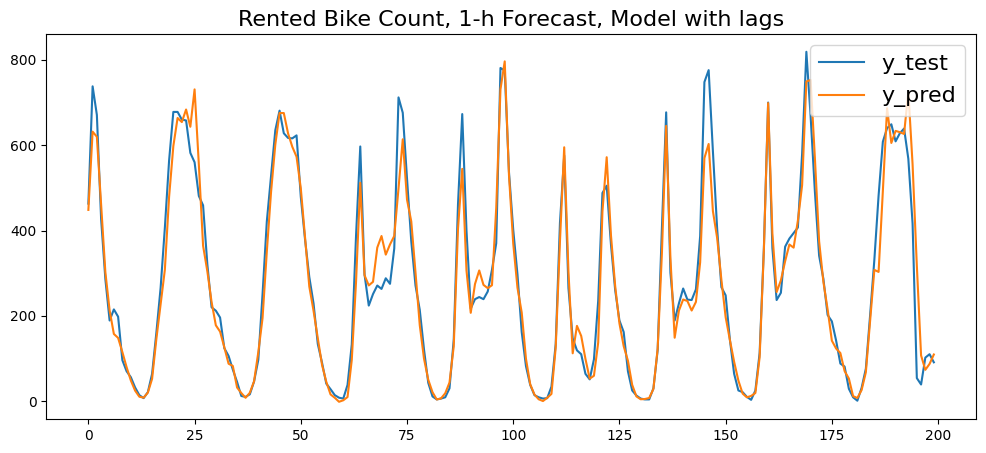

In [59]:
n = 200
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n], label='y_test')
plt.plot(y_pred[:n], label='y_pred')
plt.legend(fontsize=16)
plt.title('Rented Bike Count, 1-h Forecast, Model with lags', fontsize=16)

In [ ]:
### Save the model
model.save_model('../data/06_models/first_catboost_model.cbm')